# 02 — Topic Modeling: Latent Themes in Complaint Narratives

Fits LDA on credit reporting complaint narratives and compares the resulting topics against the CFPB's own `Issue` categories — testing whether the taxonomy already captures the structure in the text, or whether narratives cluster differently (Research Question 1).

<!-- Method follows the same LDA workflow as HW4 Q5 (gensim, pyLDAvis), applied to a new corpus and a new comparison question. -->


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/ANLP_portfolio/")


Mounted at /content/drive/


In [3]:
!pip install gensim pyLDAvis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 65.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import re
import gensim
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models
import nltk
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [5]:
nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

DATA_PATH = "data/01_complaints_credit_reporting.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)
print(df['Consumer complaint narrative'].notna().mean())  # should be 1.0 -- confirmed in 01_eda


(400445, 16)
1.0


## Deduplicating Narratives

01_eda found that 48.6% of narratives in this dataset are exact duplicates — concentrated in a small number of formulaic legal-template narratives (the top one alone appears 12,168 times), consistent with automated dispute-tool activity rather than individually written complaints.

Fitting LDA on the corpus as-is would mean roughly half the "documents" are copies of a handful of templates, which would surface those templates as dominant topics rather than reveal genuine variation in complaint content — the opposite of what Question 1 is testing. Deduplicating on exact narrative text before building the corpus.

In [6]:
before = len(df)
df = df.drop_duplicates(subset='Consumer complaint narrative').reset_index(drop=True)
after = len(df)

print(f"Rows before dedup: {before:,}")
print(f"Rows after dedup:  {after:,}")
print(f"Removed: {before - after:,} ({(before - after) / before:.1%})")

narratives = df['Consumer complaint narrative']
print(f"\n{len(narratives):,} unique narratives going into topic modeling")


Rows before dedup: 400,445
Rows after dedup:  164,533
Removed: 235,912 (58.9%)

164,533 unique narratives going into topic modeling


**Dedup result:** 400,445 → 164,533 unique narratives (235,912 removed, 58.9%). This is a larger removal than the 48.6% "rows in a duplicate group" figure from 01_eda — that's expected, not a discrepancy: 48.6% counted every occurrence of a repeated narrative, while this step keeps only one copy per unique narrative, so it also removes the "extra" repeats beyond the first. The two numbers are mathematically consistent (verified: 303,368 duplicate-group rows collapse to 67,456 distinct narratives, and 303,368 − 67,456 = 235,912).

164,533 unique narratives is the corpus going into LDA — well above the `no_below=10` threshold set in the dictionary-filtering step, so vocabulary size shouldn't be meaningfully constrained by corpus size at this scale.

## Preprocessing

CFPB narratives use `X`-masking for redacted PII (e.g. `XX/XX/XXXX`, `XXXX`) — strip that out before tokenizing, or it'll dominate the topics.

In [7]:
def clean_narrative(text):
    text = re.sub(r'X{2,}', ' ', text)          # strip PII masking
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)     # strip punctuation/numbers
    tokens = text.lower().split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return tokens

tokenized = narratives.apply(clean_narrative)
tokenized.iloc[0][:20]


['connection',
 'mentioned',
 'creditors',
 'initiate',
 'inquiry',
 'request',
 'prompt',
 'removal',
 'credit',
 'report']

**Worth checking after a first LDA run:** credit reporting narratives lean heavily on legal/statutory language (`fcra`, `fdcpa`, `usc`, `section`, `consumer`, `report`, `account`) even after deduplication, since the surviving unique narratives still borrow from similar template phrasing. If topics come back dominated by these boilerplate legal terms rather than substantive differences in complaint content, consider adding a domain-specific stopword list on top of NLTK's general one.

**Sample tokenized narrative:**

['connection', 'mentioned', 'creditors', 'initiate', 'inquiry', 'request', 'prompt', 'removal', 'credit', 'report']

Cleaning worked as intended — no leftover `XXXX` redaction fragments, no punctuation, no stopwords, everything lowercased. But the resulting vocabulary is already fairly generic and process-oriented ("creditors," "inquiry," "removal," "credit," "report") rather than pointing to a specific type of complaint.

This is one narrative, not a pattern yet, but worth watching once the actual LDA topics come out: if several topics end up dominated by this kind of generic dispute-process language rather than substantive differences between complaint types, that's the signal to add a domain-specific stopword list (`credit`, `report`, `inquiry`, `dispute`, `account`) on top of NLTK's general one — words so common across this whole corpus they won't help distinguish topics from each other.

## Build Dictionary and Corpus

In [8]:
dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=10, no_above=0.5)  # drop rare and near-universal terms
corpus = [dictionary.doc2bow(doc) for doc in tokenized]

print(f"Vocabulary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")


Vocabulary size: 9011
Corpus size: 164533


**Dictionary and corpus built:**

vocabulary size 9,011, corpus size 164,533 — one bag-of-words document per deduplicated narrative, as expected.

A vocabulary of ~9,000 terms from 164,533 documents is a reasonable size for LDA at this corpus scale — large enough to capture real topical variation, filtered down from whatever the raw vocabulary was via `no_below=10` (drops rarely-used terms) and `no_above=0.5` (drops terms so common they appear in over half of all narratives, which wouldn't help distinguish topics). Worth keeping in mind given the earlier generic-vocabulary observation: `no_above=0.5` will only catch terms appearing in *more than half* of all narratives, so moderately common process-language (appearing in, say, 20–40% of narratives) can still pass through and dominate topics. If topics come back generic rather than substantive, tightening `no_above` (e.g., to 0.3) is a faster fix to try before manually building a stopword list.

## Fit LDA

Choose `num_topics`. Since this dataset is now scoped to credit reporting only (not all products), check `df['Issue'].nunique()` on this dataset specifically — it'll be a different, likely smaller number than an all-products count would give, and it's the right comparison baseline for the cross-tab below.

In [9]:
print(f"Distinct Issue values within credit reporting: {df['Issue'].nunique()}")
print(df['Issue'].value_counts())


Distinct Issue values within credit reporting: 8
Issue
Incorrect information on your report                               102524
Improper use of your report                                         34980
Problem with a company's investigation into an existing problem     23933
Unable to get your credit report or credit score                      948
Credit monitoring or identity theft protection services               859
Problem with fraud alerts or security freezes                         772
Problem with a company's investigation into an existing issue         400
Identity theft protection or other monitoring services                117
Name: count, dtype: int64


**Distinct Issue values within credit reporting: 8** — but two pairs are very likely renamed duplicates of the same underlying category, the same taxonomy-drift pattern found earlier in `Product`:
- `'Problem with a company's investigation into an existing problem'` (23,933) and `'...existing issue'` (400)
- `'Credit monitoring or identity theft protection services'` (859) and `'Identity theft protection or other monitoring services'` (117)

Consolidating these before building the topic-vs-issue cross-tab, so a genuinely matching topic doesn't get penalized for spanning a label rename rather than a real category difference.

In [10]:
ISSUE_MERGE_MAP = {
    "Problem with a company's investigation into an existing issue": "Problem with a company's investigation into an existing problem",
    "Identity theft protection or other monitoring services": "Credit monitoring or identity theft protection services",
}
df['Issue'] = df['Issue'].replace(ISSUE_MERGE_MAP)

print(f"Distinct Issue values after consolidation: {df['Issue'].nunique()}")
print(df['Issue'].value_counts())

Distinct Issue values after consolidation: 6
Issue
Incorrect information on your report                               102524
Improper use of your report                                         34980
Problem with a company's investigation into an existing problem     24333
Credit monitoring or identity theft protection services               976
Unable to get your credit report or credit score                      948
Problem with fraud alerts or security freezes                         772
Name: count, dtype: int64


**Consolidated Issue distribution (6 categories):**

| Issue | Count | Share |
|---|---|---|
| Incorrect information on your report | 102,524 | 62.3% |
| Improper use of your report | 34,980 | 21.3% |
| Problem with a company's investigation into an existing problem | 24,333 | 14.8% |
| Credit monitoring or identity theft protection services | 976 | 0.6% |
| Unable to get your credit report or credit score | 948 | 0.6% |
| Problem with fraud alerts or security freezes | 772 | 0.5% |

Confirms the merge worked correctly (23,933 + 400 = 24,333; 859 + 117 = 976). The distribution is heavily skewed — the top two categories alone cover ~84% of narratives, while the bottom three combined are under 2%. This matters for interpreting the topic-vs-issue cross-tab later: with this much imbalance, several LDA topics landing mostly within the top two Issue categories wouldn't be surprising or especially informative on its own, since that's simply where most of the data's volume sits. The more interesting test is whether topics *within* those two dominant categories subdivide into something the Issue label itself doesn't distinguish — that would be a genuine finding beyond what the raw category sizes already predict.

## Choosing K: Coherence Score Across a Range

The Issue-count check above suggests 6 as a domain-driven starting point, but it's worth checking whether that's also supported statistically. Computing c_v coherence across a range of k values — this refits LDA five times, so it may take a few minutes on the full 164,533-document corpus.

k=4: coherence=0.4715
k=5: coherence=0.4838
k=6: coherence=0.4914
k=7: coherence=0.5046
k=8: coherence=0.4967


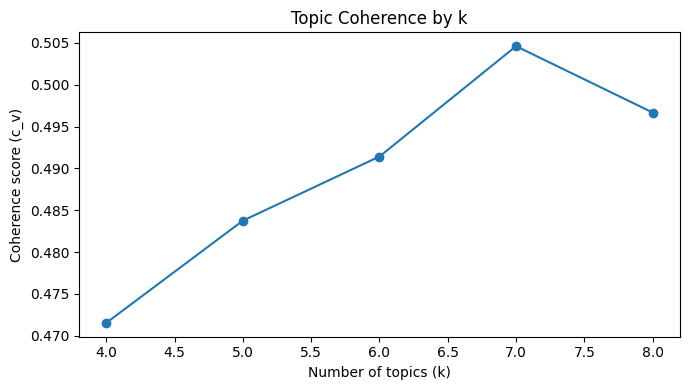

In [ ]:
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

coherence_scores = {}
topic_range = [4, 5, 6, 7, 8]

for k in topic_range:
    model_k = LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=k,
        random_state=42, passes=10, alpha='auto',
    )
    cm = CoherenceModel(model=model_k, texts=tokenized, dictionary=dictionary, coherence='c_v')
    coherence_scores[k] = cm.get_coherence()
    print(f"k={k}: coherence={coherence_scores[k]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(list(coherence_scores.keys()), list(coherence_scores.values()), marker='o')
plt.xlabel('Number of topics (k)')
plt.ylabel('Coherence score (c_v)')
plt.title('Topic Coherence by k')
plt.tight_layout()
plt.show()

## Decision: Adopting k=7

Coherence peaked at k=7 (0.5046), not k=6 (0.4914). Given the point of computing coherence was to check whether the domain-driven choice of 6 held up statistically, and it didn't quite, the honest move is to adopt the coherence-optimal value rather than keep the original pick and only acknowledge the gap in a footnote. Refitting the full pipeline — topic interpretation, pyLDAvis, prevalence, and the topic-vs-issue cross-tab — at `NUM_TOPICS=7`.

## Interactive Visualization

In [12]:
NUM_TOPICS = 7

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto',
)

for i, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {i}: {topic}")

Topic 0: 0.010*"year" + 0.010*"loan" + 0.007*"never" + 0.007*"company" + 0.006*"would" + 0.006*"time" + 0.006*"card" + 0.006*"due"
Topic 1: 0.151*"date" + 0.113*"opened" + 0.113*"number" + 0.108*"balance" + 0.047*"inquiries" + 0.025*"consumer" + 0.023*"fraudulent" + 0.021*"hard"
Topic 2: 0.053*"identity" + 0.044*"theft" + 0.033*"fraudulent" + 0.017*"inquiries" + 0.017*"unauthorized" + 0.013*"personal" + 0.013*"ftc" + 0.013*"block"
Topic 3: 0.029*"dispute" + 0.018*"please" + 0.018*"act" + 0.017*"fair" + 0.016*"request" + 0.015*"name" + 0.014*"reported" + 0.013*"number"
Topic 4: 0.095*"consumer" + 0.036*"agency" + 0.032*"usc" + 0.025*"section" + 0.017*"privacy" + 0.017*"inaccurate" + 0.013*"written" + 0.013*"reasonable"
Topic 5: 0.013*"inaccurate" + 0.011*"documentation" + 0.011*"experian" + 0.010*"debt" + 0.010*"verification" + 0.009*"transunion" + 0.009*"equifax" + 0.009*"failure"
Topic 6: 0.049*"late" + 0.040*"payment" + 0.032*"balance" + 0.026*"reported" + 0.025*"inaccurate" + 0.021*

In [14]:
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Dictionary
dictionary.save(f"{ARTIFACT_DIR}/02_lda_dictionary.dict")

# Corpus -- MmCorpus is gensim's standard on-disk sparse corpus format
corpora.MmCorpus.serialize(f"{ARTIFACT_DIR}/02_lda_corpus.mm", corpus)

# Model -- saves several companion files alongside the main one (.expElogbeta.npy, .state, etc.)
# all with the same base name; keep them together, don't rename just the main file
lda_model.save(f"{ARTIFACT_DIR}/02_lda_model.model")

print(f"Saved from Notebook 02: dictionary, corpus ({len(corpus):,} docs), "
      f"and LDA model (k={lda_model.num_topics}) to {ARTIFACT_DIR}/")

Saved from Notebook 02: dictionary, corpus (164,533 docs), and LDA model (k=7) to artifacts/


In [13]:
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)


## Interpreting the LDA Topics

| pyLDAvis # | gensim # | % tokens | Top terms | Theme |
|---|---|---|---|---|
| 1 | 5 | 25.7% | inaccurate, documentation, experian, debt, verification, transunion, equifax, failure, reinvestigation | Formal dispute-investigation process (bureaus, documentation, verification) |
| 2 | 6 | 17.1% | late, payment, balance, reported, inaccurate, date, payments, opened, inquiry | Late payment / balance inaccuracy |
| 3 | 3 | 14.5% | dispute, please, act, fair, request, name, reported, number, violation | Formal dispute-letter template language |
| 4 | 0 | 13.5% | year, loan, never, company, would, time, card, due, experian | Vehicle loan customer-service complaints |
| 5 | 2 | 12.2% | identity, theft, fraudulent, inquiries, unauthorized, personal, ftc, block | Identity theft / FCRA-violation legal language |
| 6 | 1 | 11.5% | date, opened, number, balance, inquiries, consumer, fraudulent, hard | Account-opening details + fraud signals |
| 7 | 4 | 5.5% | consumer, agency, usc, section, privacy, inaccurate, written, reasonable, permissible, purpose | Unauthorized inquiries / "permissible purpose" (statute language) |

pyLDAvis renumbers topics by prevalence, so its numbering doesn't match gensim's original topic order — confirmed by cross-checking top terms between the two views.

The intertopic distance map shows three topics clearly isolated from the rest — vehicle loan customer service, identity theft/FCRA, and unauthorized inquiries/permissible purpose — each with a distinct, coherent theme. The remaining four topics (formal investigation-process language, late-payment/balance language, dispute-letter templates, account-opening details) sit closer together and show some overlap, consistent with all four drawing on related formal/legal vocabulary even where their underlying complaint content differs.

## Topic vs. Issue Comparison

For each narrative, get its dominant LDA topic, then cross-tabulate against `df['Issue']`. High concentration (most of a topic's mass falling into one Issue category) supports the taxonomy; spread-out topics suggest narratives cut across the CFPB's own categories — the finding Question 1 is actually testing for.

Note: `corpus` and `df` are aligned by position since both were built from the same deduplicated, index-reset `df` above — no separate re-alignment needed, unlike the original version of this notebook (which had to account for a `dropna()` shifting indices).

In [16]:
def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1])[0]

dominant_topics = [get_dominant_topic(bow) for bow in corpus]
df['dominant_topic'] = dominant_topics

topic_issue_crosstab = pd.crosstab(df['dominant_topic'], df['Issue'], normalize='index')
topic_issue_crosstab

Issue,Credit monitoring or identity theft protection services,Improper use of your report,Incorrect information on your report,Problem with a company's investigation into an existing problem,Problem with fraud alerts or security freezes,Unable to get your credit report or credit score
dominant_topic,,,,,,
0,0.022885,0.173341,0.561778,0.196830,0.017341,0.027824
1,0.001573,0.086997,0.902591,0.008746,0.000000,0.000093
2,0.005257,0.195331,0.706076,0.088955,0.003917,0.000464
3,0.002509,0.218862,0.668622,0.104956,0.003560,0.001492
4,0.001128,0.600548,0.298421,0.097003,0.002095,0.000806
5,0.002373,0.187587,0.514265,0.290741,0.002257,0.002778
6,0.001314,0.309218,0.563886,0.124746,0.000478,0.000358


## Topic vs. Issue Cross-Tab: Results (k=7)

| Topic (gensim #) | Theme | Top Issue match | Concentration | Notable secondary |
|---|---|---|---|---|
| 0 | Vehicle loan customer-service | Incorrect information | 56.2% | Problem with investigation (19.7%) — the highest secondary share of any topic |
| 1 | Account-opening / fraud signals | Incorrect information | **90.3%** | — |
| 2 | Identity theft / FCRA legal | Incorrect information | 70.6% | Improper use (19.5%) |
| 3 | Dispute-letter template | Incorrect information | 66.9% | Improper use (21.9%) |
| 4 | Unauthorized inquiries / permissible purpose | **Improper use** | **60.1%** | Incorrect information (29.8%) |
| 5 | Formal dispute-investigation process | Incorrect information | 51.4% | Problem with investigation (29.1%) |
| 6 | Late payment / balance inaccuracy | Incorrect information | 56.4% | Improper use (30.9%) |

**Topic 4 remains the one clean, semantically correct match — and it's consistent across both k=6 and k=7.** This topic's vocabulary (agency, usc, section, permissible, purpose) is a textbook match for "Improper use of your report," and it's the only topic where the taxonomy's own category distinction lines up with what LDA found independently, regardless of how many topics the model is asked to find. That consistency is stronger evidence for this specific finding than either single run alone.

**Topic 1's 90.3% concentration is unchanged from k=6** — this is the same near-duplicate-template-driven topic identified earlier (the FCRA §605B "block this information" letter, with only the bureau name swapped between copies). Splitting the corpus into 7 topics instead of 6 didn't touch this one; it remained intact, which makes sense since it's less "one coherent theme" than "one template repeated at scale," and no amount of re-splitting elsewhere changes that.

**The k=7 split did produce a real, useful differentiation.** At k=6, "formal investigation process" and "late payment/balance" were tangled into one 31%-of-corpus topic. Split apart, they now show measurably different secondary Issue affinities: Topic 5 (investigation-process language) leans toward "Problem with a company's investigation" (29.1%), while Topic 6 (late-payment language) leans toward "Improper use" (30.9%) instead. Coherence's suggestion to split this topic wasn't just a statistical nicety — it recovered a real distinction the k=6 model was blurring together.

**Unchanged limitation:** none of the 7 topics concentrate meaningfully in the three minority Issue categories (Credit monitoring, fraud alerts, unable to get report) — all stay under ~3%, most under 1%. The severe class imbalance in Issue labels still means this analysis can't speak to whether those categories have distinct narrative signatures of their own.

In [17]:
TOPIC_NAMES = {
    0: "Vehicle Loan Customer-Service Complaints",
    1: "Account-Opening Details / Fraud Signals",
    2: "Identity Theft / FCRA-Violation Legal Language",
    3: "Dispute-Letter Template Language",
    4: "Unauthorized Inquiries / Permissible Purpose",
    5: "Formal Dispute-Investigation Process",
    6: "Late Payment / Balance Inaccuracy",
}
df['topic_name'] = df['dominant_topic'].map(TOPIC_NAMES)

## Topic Prevalence Across the Corpus

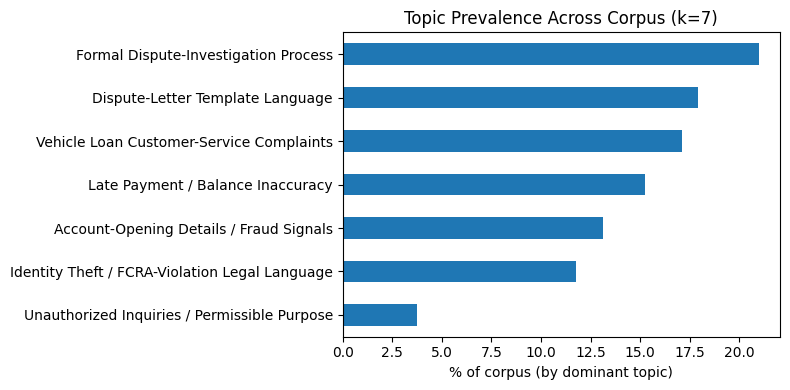

,proportion
dominant_topic,
Account-Opening Details / Fraud Signals,13.1
Dispute-Letter Template Language,17.9
Formal Dispute-Investigation Process,21.0
Identity Theft / FCRA-Violation Legal Language,11.8
Late Payment / Balance Inaccuracy,15.3
Unauthorized Inquiries / Permissible Purpose,3.8
Vehicle Loan Customer-Service Complaints,17.1


In [20]:
import matplotlib.pyplot as plt
topic_share = df['dominant_topic'].map(TOPIC_NAMES).value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 4))
topic_share.sort_values().plot(kind='barh')
plt.xlabel('% of corpus (by dominant topic)')
plt.ylabel('')
plt.title('Topic Prevalence Across Corpus (k=7)')
plt.tight_layout()
plt.show()
topic_share.round(1)

## Prevalence by Document Count vs. Token Share

The chart above measures topics by **share of narratives** where each topic is dominant; pyLDAvis's earlier percentages measured **share of tokens** across the whole corpus. These mostly agree in rank order, but diverge notably for one topic:

| Topic | Token share (pyLDAvis) | Document share (this chart) |
|---|---|---|
| Formal Dispute-Investigation Process | 25.7% | 21.0% |
| Dispute-Letter Template Language | 14.5% | 17.9% |
| Vehicle Loan Customer-Service Complaints | 13.5% | 17.1% |
| Late Payment / Balance Inaccuracy | 17.1% | 15.3% |
| Account-Opening Details / Fraud Signals | 11.5% | 13.1% |
| Identity Theft / FCRA-Violation Legal Language | 12.2% | 11.8% |
| **Unauthorized Inquiries / Permissible Purpose** | **5.5%** | **3.8%** |

Most topics shift only modestly between the two measures — expected, since narrative length varies topic to topic. But **Unauthorized Inquiries / Permissible Purpose is the smallest topic by a wide margin on both measures**, and shrinks further under document share (3.8% vs. 5.5%). Combined with the earlier finding that this is also the *one topic that cleanly matches its own Issue category* ("Improper use of your report"), there's a real tension worth naming directly: the topic doing the best job validating the CFPB's taxonomy is also the rarest one in this dataset. A clean semantic match on a small minority of narratives is a real finding, but it's not evidence the taxonomy generally holds — it's evidence the taxonomy holds specifically where a narrow, easily-identified legal pattern (statute citation, "permissible purpose" language) exists in the text.

By contrast, **Formal Dispute-Investigation Process is the single most common topic (21.0% of narratives)** and one of the topics that concentrates heavily but generically in "Incorrect information on your report" (51.4%) rather than mapping to anything more specific — the dominant pattern in this dataset is a large, generic-accuracy-dispute topic, not one that cleanly maps to the taxonomy's finer distinctions.

## Limitations

- LDA treats narratives as unordered bags of words — word order, negation, and sentence structure are discarded, so topics reflect co-occurring vocabulary, not grammatical meaning.
- Results are sensitive to preprocessing choices made along the way: exact-match-only deduplication (confirmed to miss near-duplicate templates with minor variations, like Topic 1's bureau-name swaps), `no_below`/`no_above` vocabulary filtering, and the choice not to lemmatize.
- CFPB's `Issue` labels are self-reported by consumers at submission time, not verified or audited — they're an imperfect proxy for "true" complaint category, not ground truth to score LDA against.
- The severe class imbalance in Issue categories (three categories under 2% combined) means this analysis can't speak to whether minority categories have their own distinct narrative signature — no topic organized around them with enough volume to test that.
- The one topic that maps cleanly onto its own Issue category (Unauthorized Inquiries / Permissible Purpose) is also the rarest topic in the corpus (3.8% of narratives) — a real but narrow validation of the taxonomy, not evidence it holds broadly.

## Takeaway and Transition to Notebook 03

At k=7, LDA found one topic — Unauthorized Inquiries / Permissible Purpose — that maps cleanly onto its own CFPB Issue category, but it's also the smallest topic in the corpus (3.8% of narratives). Elsewhere, most topics concentrate in "Incorrect information on your report," though that concentration is substantially driven by template duplication rather than genuine thematic overlap — Topic 1's 90.3% concentration traces back to a small number of near-duplicate dispute letters. Formal investigation-process language and late-payment language emerged as separate topics with distinguishable secondary Issue affinities, showing the model can pick up finer distinctions than the dominant "Incorrect information" category alone suggests.

Net: the taxonomy is validated narrowly, missed elsewhere, and its apparent alignment across most of the corpus is entangled with automated-dispute-tool duplication rather than a clean read on organic narrative content.

**Next:** `03_ner_entity_extraction.ipynb` — extracting structured entities from these narratives, on the same deduplicated dataset.

In [21]:
#save file for furture
df[['Complaint ID', 'dominant_topic', 'topic_name']].to_csv(
    "data/02_complaints_topics.csv", index=False
)
print(f"Saved from Notebook 02: {df.shape[0]:,} rows")

Saved from Notebook 02: 164,533 rows
